## Notebook for making figures 

In [48]:
from pathlib import Path
from datetime import datetime
from time import time

import numpy as np
import pandas as pd
import xarray as xr
import rioxarray as rxa
from rasterio.enums import Resampling
import matplotlib.pyplot as plt
import matplotlib.colors as pltcolors
import matplotlib.cm as cm
import contextily as ctx

from uavsar_pytools.convert.tiff_conversion import read_annotation
from uavsar_pytools.georeference import geolocate_uavsar

import sys
import os

scripts_dir = (os.path.dirname(os.getcwd()) + '/scripts/')
sys.path.append(scripts_dir)

from plotting import plot_tifs_grid, plot_coherence_matrix
from coherence import calc_coherence_unweighted, calc_coherence_matrix
from taus import decorrelation_temporal_model

ModuleNotFoundError: No module named 'contextily'

In [4]:
data_dir = '../data/snowex_lowman/'
slc_dir = data_dir + 'slcs_geocoded/'
coh_dir = data_dir + 'coherences/'
tau_dir = data_dir + 'taus/'
snotel_dir = data_dir + 'snotel/'
qsi_dir = data_dir + 'snex_qsi_lidar/'

fig_dir = '../outputs/figures/insar_final_proj/'

In [76]:
# set the default style of the plots to the seaborn style
# print(plt.style.available)
plt.style.use('seaborn-v0_8')

### Background 

- ?

### Methods

- A map showing the UAVSAR flights, the Mores Creek Summit area, the location of the Snotel site
- The Mores Creek DEM with hillshading 
- The Vegetation height of Mores Creek 
- The location of the Snotel site 

In [59]:
# load one UAVSAR flight
uavsar_fp = slc_dir + 'lowman_05208_20002_006_200131_L090VV_01_BU_s2_2x8_geoslc.tif'
uavsar = rxa.open_rasterio(uavsar_fp, masked=True).squeeze()

# load Mores Creek DEM and resample
res = 5  # desired resolution in meters
dem_raw = rxa.open_rasterio(qsi_dir + 'SNEX20_QSI_DEM_0.5M_USIDMC_20210917_20210917.tif')
resampled_dem = dem_raw.rio.reproject(dem_raw.rio.crs, resampling=Resampling.average, resolution=(res, res))
dem = resampled_dem.rio.reproject(uavsar.rio.crs)
dem = dem.squeeze()  # remove band dimension
dem = dem.where(dem != dem.rio.nodata)  # set nodata values to NaN

# Snotel site 
snotel_site = (43.9333, -115.6667)

In [57]:
# create a map showing the UAVSAR flights, the Mores Creek Summit area, the location of the Snotel site


# find a satellite imagery basemap for context
import contextily as ctx

basemap, basemap_transform = ctx.bounds2raster(uavsar.rio.bounds()[0], uavsar.rio.bounds()[1],
                                               uavsar.rio.bounds()[2], uavsar.rio.bounds()[3],
                                               zoom=10, ll=True, source=ctx.providers.Esri.WorldImagery)
# plot basemap
fig, ax = plt.subplots(figsize=(10, 10))
ax.imshow(basemap.transpose(1, 2, 0), extent=uavsar.rio.bounds(), origin='upper')
ax.set_title('UAVSAR Flight Area with Basemap')
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')

ModuleNotFoundError: No module named 'contextily'

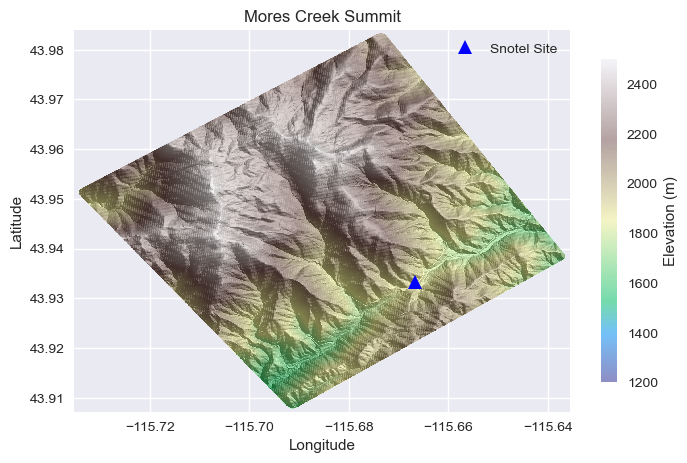

In [77]:
# plot hillshade and DEM 
from matplotlib.colors import LightSource

# create hillshade from DEM
ls = LightSource(azdeg=60, altdeg=60)
hillshade = ls.hillshade(dem.values, vert_exag=1)

# print(hillshade.shape)
dem_shade = dem.copy(data = hillshade)

# plot DEM with hillshading
# plt.style.use('light_background')
fig, ax = plt.subplots(figsize=(8, 6))
# ax = plt.gca() # Get current axes

# Plot hillshade as the base layer
hs = dem_shade.plot(ax=ax, cmap='gray', add_colorbar=False)
elev = dem.plot(ax=ax, cmap='terrain', vmin=1200, vmax=2500, add_colorbar=False, alpha=0.5) 
snotel = ax.plot(snotel_site[1], snotel_site[0], marker='^', color='blue', linestyle='None', markersize=10, label='Snotel Site')
ax.legend(frameon=False, loc='upper right')
ax.set_aspect('equal')
ax.grid(True)
ax.set_axisbelow(True)
# ax.set_facecolor('darkgray')

plt.title("Mores Creek Summit")
plt.colorbar(elev, alpha = 1, label="Elevation (m)", shrink=0.7)
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.show()

# save figure
fig.savefig(fig_dir + 'mores_creek_dem_hillshade.png', dpi=300)


### Temporal coherence model 

- A plot showing what tau and gamma infinity correspond to 
- A histogram of fitted gamma infinities

### Results 

- Map of tau values 
- Principal components analysis using vegetation height, incidence angle